# Missing Data Patterns

This example demonstrates how to generate realistic time series with various missing data patterns: random, block, and seasonal. These are useful for testing imputation methods and evaluating forecasting models under missing data.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from synforecast.generators import RandomWalkGenerator, SeasonalGenerator

## Random Missing Data Pattern

Each observation has an independent 15% probability of being missing.

In [ ]:
params_random = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "missing_data": True,
    "missing_pattern": "random",
    "missing_rate": 0.15,
    "seed": 42,
}

gen_random = RandomWalkGenerator(engine="polars", **params_random)
df_random = gen_random.generate(n_series=1)

print(f"Generated {len(df_random)} daily observations")
df_random.head(20)

Generated 200 daily observations


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.401594
"""0""",2000-01-02 00:00:00,-2.307539
"""0""",2000-01-03 00:00:00,-1.352484
"""0""",2000-01-04 00:00:00,-1.011828
"""0""",2000-01-05 00:00:00,-1.511372
…,…,…
"""0""",2000-01-16 00:00:00,-1.602961
"""0""",2000-01-17 00:00:00,-2.194502
"""0""",2000-01-18 00:00:00,-0.974393


In [ ]:
values = df_random["y"].to_numpy()
nan_count = np.sum(np.isnan(values))
nan_rate = nan_count / len(values)

print(f"Missing data statistics:")
print(f"  Missing values:     {nan_count} ({nan_rate:.1%})")
print(f"  Complete values:    {len(values) - nan_count} ({1-nan_rate:.1%})")

non_nan_values = values[~np.isnan(values)]
if len(non_nan_values) > 0:
    print(f"  Non-missing mean:   {non_nan_values.mean():.2f}")
    print(f"  Non-missing std:    {non_nan_values.std():.2f}")

Missing data statistics:
  Missing values:     30 (15.0%)
  Complete values:    170 (85.0%)
  Non-missing mean:   7.08
  Non-missing std:    5.47


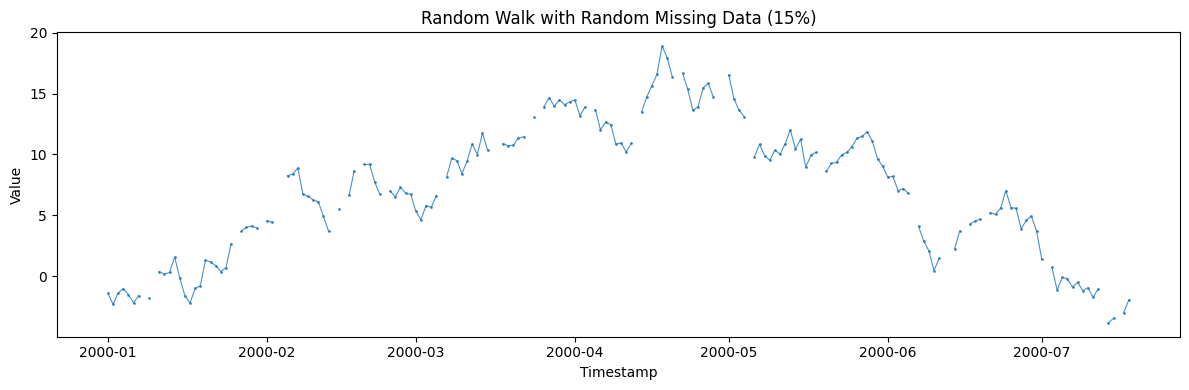

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
series = df_random.filter(pl.col("unique_id") == "0")
ax.plot(series["ds"].to_list(), series["y"].to_list(), alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Random Walk with Random Missing Data (15%)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## Block Missing Data Pattern (Sensor Outages)

Missing data occurs in contiguous blocks of 5 consecutive days, simulating sensor outages or system downtime.

In [ ]:
params_block = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "missing_data": True,
    "missing_pattern": "block",
    "missing_rate": 0.2,
    "missing_block_size": 5,
    "seed": 123,
}

gen_block = RandomWalkGenerator(engine="polars", **params_block)
df_block = gen_block.generate(n_series=1)

print(f"Generated {len(df_block)} daily observations")
print(f"Missing blocks of size: {params_block['missing_block_size']} days")
df_block.head(30)

Generated 200 daily observations
Missing blocks of size: 5 days


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.648263
"""0""",2000-01-02 00:00:00,-2.785263
"""0""",2000-01-03 00:00:00,-3.426808
"""0""",2000-01-04 00:00:00,-4.329042
"""0""",2000-01-05 00:00:00,-4.296375
…,…,…
"""0""",2000-01-26 00:00:00,-8.303371
"""0""",2000-01-27 00:00:00,-7.850564
"""0""",2000-01-28 00:00:00,-9.064892


In [ ]:
values_block = df_block["y"].to_numpy()
nan_count_block = np.sum(np.isnan(values_block))
nan_rate_block = nan_count_block / len(values_block)

# Find longest missing block
max_consecutive = 0
current_consecutive = 0
for val in values_block:
    if np.isnan(val):
        current_consecutive += 1
        max_consecutive = max(max_consecutive, current_consecutive)
    else:
        current_consecutive = 0

print(f"Block missing statistics:")
print(f"  Missing values:     {nan_count_block} ({nan_rate_block:.1%})")
print(
    f"  Complete values:    {len(values_block) - nan_count_block} ({1-nan_rate_block:.1%})"
)
print(f"  Longest missing block: {max_consecutive} consecutive days")

Block missing statistics:
  Missing values:     40 (20.0%)
  Complete values:    160 (80.0%)
  Longest missing block: 5 consecutive days


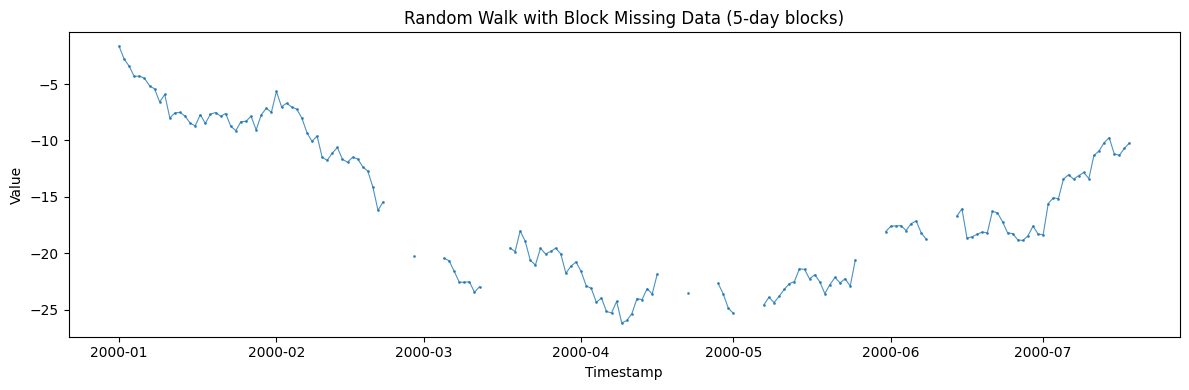

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
series = df_block.filter(pl.col("unique_id") == "0")
ax.plot(series["ds"].to_list(), series["y"].to_list(), alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Random Walk with Block Missing Data (5-day blocks)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## Seasonal Missing Data Pattern (Weekend Reporting Gaps)

Missing data follows a weekly seasonal pattern, simulating weekend reporting gaps in business data.

In [ ]:
params_seasonal = {
    "min_length": 365,
    "max_length": 365,
    "freq": "D",
    "missing_data": True,
    "missing_pattern": "seasonal",
    "missing_rate": 0.12,
    "missing_seasonal_period": 7,
    "seed": 456,
}

gen_seasonal = SeasonalGenerator(engine="polars", **params_seasonal)
df_seasonal = gen_seasonal.generate(n_series=1)

values_seasonal = df_seasonal["y"].to_numpy()
nan_count_seasonal = np.sum(np.isnan(values_seasonal))

print(f"Generated {len(df_seasonal)} daily observations (1 year)")
print(f"Seasonal period: {params_seasonal['missing_seasonal_period']} days (weekly)")
print(
    f"Missing values: {nan_count_seasonal} ({nan_count_seasonal/len(values_seasonal):.1%})"
)
df_seasonal.head(40)

Generated 365 daily observations (1 year)
Seasonal period: 7 days (weekly)
Missing values: 37 (10.1%)


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,49.395599
"""0""",2000-01-02 00:00:00,52.491517
"""0""",2000-01-03 00:00:00,54.67221
"""0""",2000-01-04 00:00:00,57.221149
"""0""",2000-01-05 00:00:00,59.057598
…,…,…
"""0""",2000-02-05 00:00:00,52.050534
"""0""",2000-02-06 00:00:00,48.371681
"""0""",2000-02-07 00:00:00,47.295235


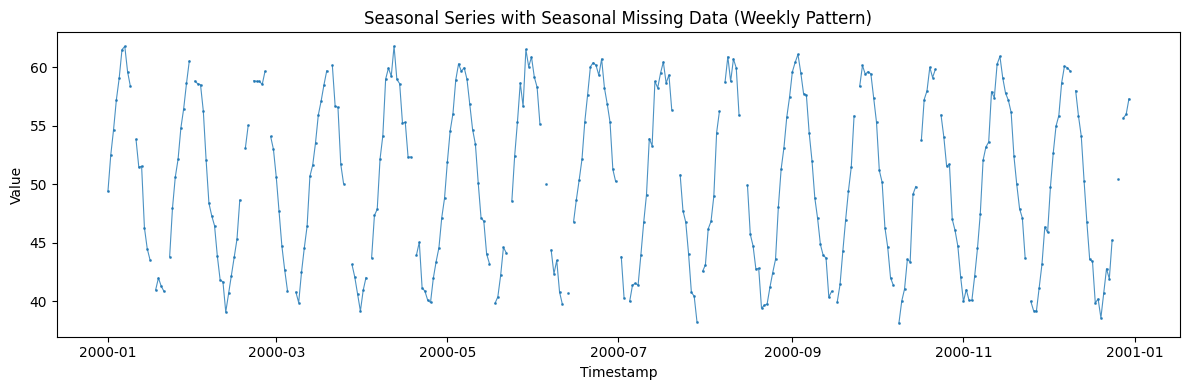

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
series = df_seasonal.filter(pl.col("unique_id") == "0")
ax.plot(series["ds"].to_list(), series["y"].to_list(), alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Seasonal Series with Seasonal Missing Data (Weekly Pattern)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

### Missing Rate by Day of Week

Analyze how the missing rate varies across the week.

In [ ]:
df_seasonal_with_week = df_seasonal.with_columns(
    [
        (pl.col("ds").dt.ordinal_day() % 7).alias("day_of_week"),
        pl.col("y").is_nan().alias("is_missing"),
    ]
)

week_stats = (
    df_seasonal_with_week.group_by("day_of_week")
    .agg(
        [
            pl.col("is_missing").sum().alias("missing_count"),
            pl.col("is_missing").count().alias("total_count"),
        ]
    )
    .with_columns(
        [
            (pl.col("missing_count") / pl.col("total_count") * 100).alias(
                "missing_rate_pct"
            )
        ]
    )
    .sort("day_of_week")
)
week_stats

day_of_week,missing_count,total_count,missing_rate_pct
i16,u32,u32,f64
0,3,52,5.769231
1,4,53,7.54717
2,7,52,13.461538
3,14,52,26.923077
4,5,52,9.615385
5,4,52,7.692308
6,0,52,0.0


## Comparing Different Missing Rates

Compare target vs actual missing rates across different settings.

In [ ]:
missing_rates = [0.05, 0.15, 0.30]
results = {}

for rate in missing_rates:
    params = {
        "min_length": 300,
        "max_length": 300,
        "freq": "D",
        "missing_data": True,
        "missing_pattern": "random",
        "missing_rate": rate,
        "seed": 789,
    }

    gen = RandomWalkGenerator(engine="polars", **params)
    df = gen.generate(n_series=1)

    values = df["y"].to_numpy()
    nan_count = np.sum(np.isnan(values))
    results[rate] = {
        "target_rate": rate * 100,
        "actual_count": nan_count,
        "actual_rate": (nan_count / len(values)) * 100,
    }

print(f"{'Target Rate':<15} {'Actual Count':<15} {'Actual Rate':<15}")
print("-" * 45)
for rate, stats in results.items():
    print(
        f"{stats['target_rate']:<15.1f} {stats['actual_count']:<15} {stats['actual_rate']:<15.1f}"
    )

Target Rate     Actual Count    Actual Rate    
---------------------------------------------
5.0             15              5.0            
15.0            45              15.0           
30.0            90              30.0           


## Multiple Series with Independent Missing Patterns

Each series gets its own independent missing data pattern.

In [ ]:
params_multi = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "missing_data": True,
    "missing_pattern": "random",
    "missing_rate": 0.2,
    "seed": 1234,
}

gen_multi = RandomWalkGenerator(engine="polars", **params_multi)
df_multi = gen_multi.generate(n_series=3)

print(f"Generated 3 series with missing data")
print(f"Total rows: {len(df_multi)}")
print(f"Unique series IDs: {df_multi['unique_id'].unique().to_list()}")

print(f"\nMissing data statistics by series:")
for series_id in df_multi["unique_id"].unique().sort():
    series_df = df_multi.filter(pl.col("unique_id") == series_id)
    values = series_df["y"].to_numpy()
    nan_count = np.sum(np.isnan(values))
    nan_rate = nan_count / len(values)
    print(f"  {series_id}: {nan_count} missing ({nan_rate:.1%})")

Generated 3 series with missing data
Total rows: 300
Unique series IDs: ['0', '1', '2']

Missing data statistics by series:
  0: 20 missing (20.0%)
  1: 20 missing (20.0%)
  2: 20 missing (20.0%)


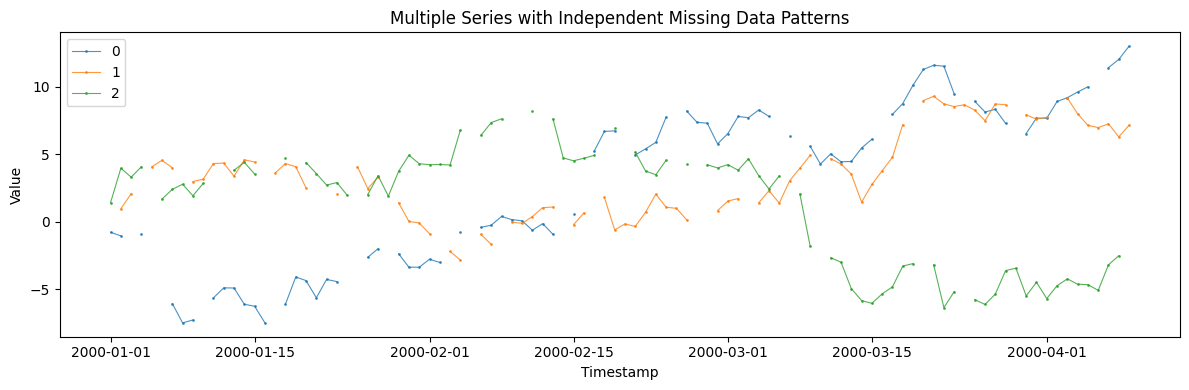

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_multi["unique_id"].unique().to_list():
    series = df_multi.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Multiple Series with Independent Missing Data Patterns")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()